# Amazon 1P/3P Analysis - Non-mattress

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [2]:
import os
import sys

import io
from io import BytesIO
import csv

import google.auth
from google.cloud import bigquery
#from google.cloud import bigquery_storage

In [3]:
import re
from sklearn.feature_extraction.text import CountVectorizer
#from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import MultipleLocator, FuncFormatter
from wordcloud import WordCloud, STOPWORDS

In [4]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "./market-analysis-project-91130-9f9a036682b6.json"

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

bqclient = bigquery.Client(credentials=credentials, project=project_id,)

In [5]:
sql = f"""
SELECT * FROM `wook.stckln_amz_non_mattress_ms_trend` 
WHERE yr_month >= '24-01'
"""

df = bqclient.query(sql).to_dataframe()

In [11]:
print(df)

        RetailerSku gpt_financial_category gpt_sub_category gpt_style_type  \
0        B09Q65158X                   None             None           None   
1        B0CGN8XHGW                   None             None           None   
2        B0BM4TQHZF                   None             None           None   
3        B0CN6N8HGV                   None             None           None   
4        B0CFXQPB8P                   None             None           None   
...             ...                    ...              ...            ...   
1328153  B0844XB9B1       20.PLATFORM BEDS          Wood PB           None   
1328154  B0D6Z2NLZ5       20.PLATFORM BEDS          Wood PB      Headboard   
1328155  B0B8SH1T7D       20.PLATFORM BEDS          Wood PB           None   
1328156  B0D33YMVFM       20.PLATFORM BEDS          Wood PB           None   
1328157  B0CT58RQD3                   None              etc           None   

                                        rf_categories_flat rf_c

In [13]:
df1 = df.copy()

In [15]:
# yr_month에서 year 추출
df1['year'] = df1['yr_month'].str[:2].astype(int) + 2000

# 확인
print(df1[['yr_month', 'year']].head())

  yr_month  year
0    24-01  2024
1    24-01  2024
2    24-01  2024
3    24-01  2024
4    24-01  2024


In [17]:
df1['yr_week'].min()

'Y24 W01'

In [19]:
df1.groupby('year')['RetailerSku'].nunique()

year
2024    73587
2025    55586
Name: RetailerSku, dtype: int64

In [21]:
# 1) yr_month >= '25-01' 조건 필터
df_2025 = df1[df1['year'] == 2025].copy()

# 2) 그룹바이: bw_ff_type
result = (
    df_2025.groupby('bw_ff_type', dropna=False)
    .agg(
        unique_sku=('RetailerSku', 'nunique'),   # distinct 개수
        total_sales=('RetailSales', 'sum')       # 매출 합계
    )
    .reset_index()
)

print(result)

  bw_ff_type  unique_sku   total_sales
0         1p       11088  3.781482e+08
1         2p        3573  2.246847e+08
2         3p       19510  4.486649e+08
3        NaN       21415  1.912642e+08


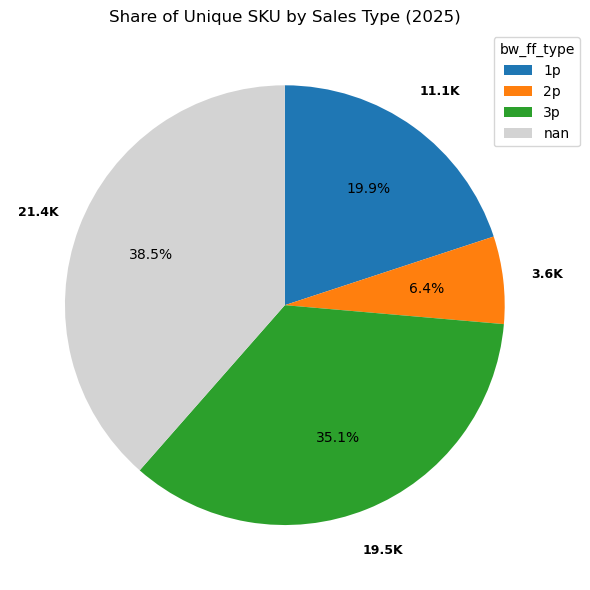

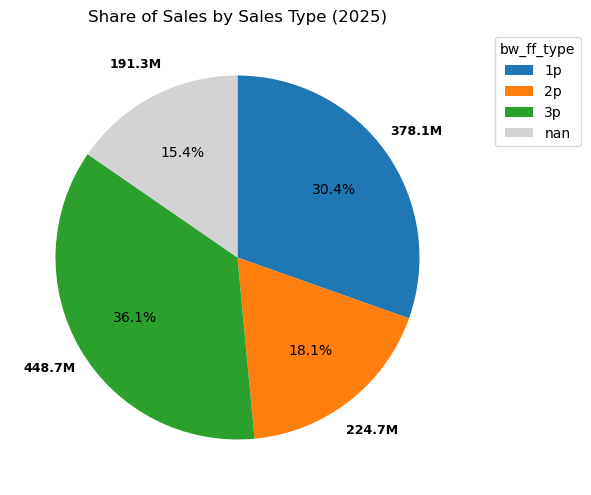

In [23]:
# 색상 매핑
colors = {
    '1p': '#1f77b4',    # 파랑
    '2p': '#ff7f0e',    # 주황
    '3p': '#2ca02c',    # 초록
    None: 'lightgray',  # NaN → 회색
    'Null': 'lightgray'
}
# result['bw_ff_type'] 값에 따라 색상 지정
pie_colors = [colors.get(v, 'lightgray') for v in result['bw_ff_type']]

# --------- 1) Unique SKU 기준 파이차트 ---------
fig, ax = plt.subplots(figsize=(6,6))
wedges, texts, autotexts = ax.pie(
    result['unique_sku'],
    labels=None,
    autopct="%.1f%%",         # % 표시
    startangle=90,
    counterclock=False,
    colors=pie_colors,
    pctdistance=0.65          # %를 안쪽에
)

# 유니크 SKU 개수 바깥쪽에 표시 (K 단위, 소수점 1자리)
for i, w in enumerate(wedges):
    ang = (w.theta2 - w.theta1)/2. + w.theta1
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))
    sku_val = result['unique_sku'].iloc[i]
    sku_k = sku_val / 1000.0
    ax.text(
        x*1.2, y*1.2, f"{sku_k:.1f}K",   # 소수점 1자리 + K
        ha='center', va='center', fontsize=9, weight='bold', color="black"
    )

ax.legend(result['bw_ff_type'], title="bw_ff_type", bbox_to_anchor=(1.05, 1))
ax.set_title("Share of Unique SKU by Sales Type (2025)")
plt.tight_layout()
plt.show()

# --------- 2) Sales 기준 파이차트 ---------
fig, ax = plt.subplots(figsize=(6,6))
wedges, texts, autotexts = ax.pie(
    result['total_sales'],
    labels=None,
    autopct="%.1f%%",         # % 표시
    startangle=90,
    counterclock=False,
    colors=pie_colors,
    pctdistance=0.65          # %를 안쪽에
)

# 매출(Million) 바깥쪽에 표시
for i, w in enumerate(wedges):
    ang = (w.theta2 - w.theta1)/2. + w.theta1
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))
    val_million = result['total_sales'].iloc[i] / 1e6
    ax.text(
        x*1.2, y*1.2, f"{val_million:.1f}M",  # Million 단위
        ha='center', va='center', fontsize=9, weight='bold', color="black"
    )

ax.legend(result['bw_ff_type'], title="bw_ff_type", bbox_to_anchor=(1.05, 1))
ax.set_title("Share of Sales by Sales Type (2025)")
plt.tight_layout()
plt.show()

In [42]:
# 1. 2025년 데이터만 필터링
df_2025 = df1[df1['year'] == 2025].copy()

# 2. bw_ff_type의 NaN → 'None' 변환
df_2025['bw_ff_type'] = df_2025['bw_ff_type'].fillna('None')

# 3. SKU별 최신 주차 데이터만 남기기
#df_2025_sorted = df_2025.sort_values(['RetailerSku', 'WeekEnding'])
#latest_2025 = df_2025_sorted.groupby('RetailerSku').tail(1)

# 4. category × bw_ff_type별 unique SKU 개수 집계
sku_counts = (
    df_2025.groupby(['gpt_sub_category', 'bw_ff_type'])['RetailerSku']
               .nunique()
               .reset_index(name='sku_count')
)

# 5. Pivot 변환 (개수 테이블)
sku_pivot = (
    sku_counts.pivot(index='gpt_sub_category', columns='bw_ff_type', values='sku_count')
              .fillna(0)
)

# 6. 컬럼 순서 고정
desired_cols = ['1p','2p','3p','None']
for c in desired_cols:
    if c not in sku_pivot.columns:
        sku_pivot[c] = 0
sku_pivot = sku_pivot[desired_cols].astype(int)

# 7. 비중 계산
sku_ratio = sku_pivot.div(sku_pivot.sum(axis=1), axis=0) * 100

# 8. 출력
print("▶ 2025 category별 SKU 개수")
print(sku_pivot)

print("\n▶ 2025 category별 SKU 비중 (%)")
print(sku_ratio.round(1))

▶ 2025 category별 SKU 개수
bw_ff_type               1p    2p    3p  None
gpt_sub_category                             
Adjustable Bed           11     0    29    25
Box Springs             306   452   115   396
Bunk Bed                592    16  1509   836
Daybed                 1235    44  1933  1712
Frames for Box Spring    79    66   110   183
Guest Bed               133     8   275   167
Metal PB               1155  1639  1070  2352
Mixed PB                694   261  1565  2023
Platform Beds             0     3     0     0
SmartBases               61    37    46    93
Upholstered PB         3602   498  6447  7019
Wood PB                1281   264  2189  2401
etc                     314    51   788   567

▶ 2025 category별 SKU 비중 (%)
bw_ff_type               1p     2p    3p  None
gpt_sub_category                              
Adjustable Bed         16.9    0.0  44.6  38.5
Box Springs            24.1   35.6   9.1  31.2
Bunk Bed               20.0    0.5  51.1  28.3
Daybed                

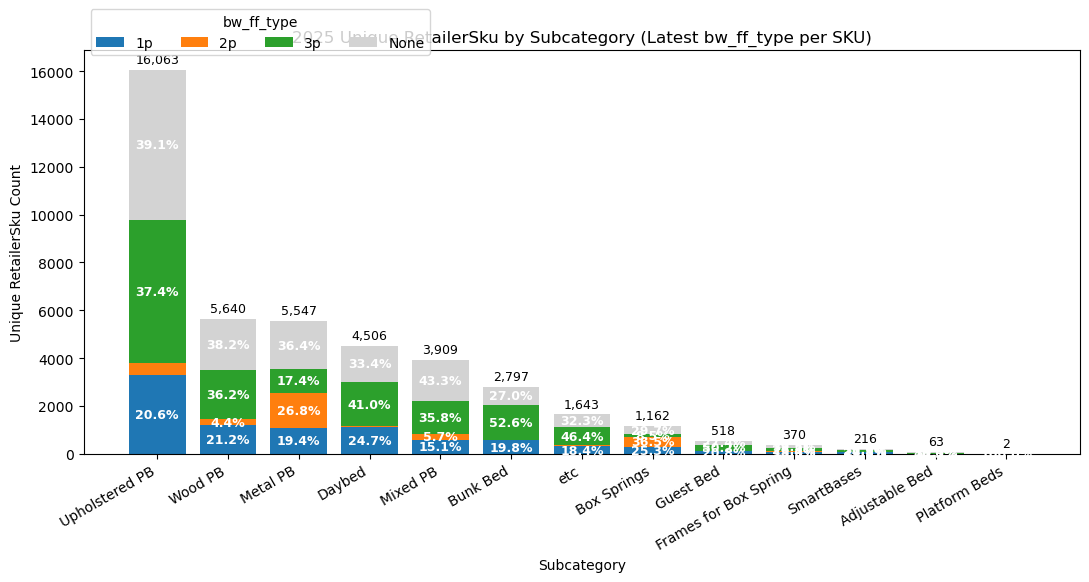

In [35]:
# ─────────────────────────────────────────────────────────
# (선택) 보기 좋게 subcategory를 총합 기준 내림차순 정렬
# ─────────────────────────────────────────────────────────
sku_pivot_sorted = sku_pivot.assign(_total=sku_pivot.sum(axis=1)) \
                            .sort_values('_total', ascending=False) \
                            .drop(columns=['_total'])
sku_ratio_sorted = sku_ratio.loc[sku_pivot_sorted.index]

# 색상 매핑 (None=회색)
colors = {'1p':'#1f77b4', '2p':'#ff7f0e', '3p':'#2ca02c', 'None':'lightgray'}
plot_cols = ['1p','2p','3p','None']  # 누적 순서

# ─────────────────────────────────────────────────────────
# 그래프 그리기 (누적 막대)
# ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

bottom = np.zeros(len(sku_pivot_sorted))
x = np.arange(len(sku_pivot_sorted))

for col in plot_cols:
    values = sku_pivot_sorted[col].values
    ax.bar(x, values, bottom=bottom, label=col, color=colors[col])
    bottom += values

# 제목/축/눈금
ax.set_title("2025 Unique RetailerSku by Subcategory (Latest bw_ff_type per SKU)")
ax.set_xlabel("Subcategory")
ax.set_ylabel("Unique RetailerSku Count")
ax.set_xticks(x)
ax.set_xticklabels(sku_pivot_sorted.index, rotation=30, ha='right')

# 범례
ax.legend(title="bw_ff_type", ncol=4, loc='upper left', bbox_to_anchor=(0, 1.12))

# ─────────────────────────────────────────────────────────
# 각 세그먼트에 비중(%) 라벨 표시 (3% 미만은 생략)
# ─────────────────────────────────────────────────────────
min_ratio_to_show = 3.0  # 필요 시 조정
for i, sub in enumerate(sku_pivot_sorted.index):
    y_base = 0
    for col in plot_cols:
        count = sku_pivot_sorted.loc[sub, col]
        if count <= 0:
            continue
        ratio = sku_ratio_sorted.loc[sub, col]
        if ratio >= min_ratio_to_show:
            ax.text(
                i,
                y_base + count/2,
                f"{ratio:.1f}%",
                ha='center', va='center',
                fontsize=9, color='white', weight='bold'
            )
        y_base += count

# (선택) 총합 라벨 막대 위에 표시
totals = sku_pivot_sorted.sum(axis=1)
for i, val in enumerate(totals):
    ax.text(i, val + max(totals)*0.01, f"{int(val):,}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [25]:
# 1. 2025년 데이터만 추출
df_2025 = df1[df1['year'] == 2025].copy()

# 2. bw_ff_type의 NaN → 'None' 변환
df_2025['bw_ff_type'] = df_2025['bw_ff_type'].fillna('None')

# 브랜드명 정규화 (대문자 + 공백 제거)
df_2025['Brand_raw'] = df_2025['Brand_raw'].str.strip().str.upper()

# 다시 집계
brand_sales = (
    df_2025.groupby('Brand_raw', dropna=False)['RetailSales']
      .sum()
      .sort_values(ascending=False)
)

print("▶ Top 20 브랜드")
print(brand_sales.head(20))

top20_brands = list(brand_sales.head(20).index)

# 필터링
df_top = df_2025[df_2025['Brand_raw'].isin(top20_brands)].copy()

pivot_sales = (
    df_top.pivot_table(
        index='Brand_raw',
        columns='bw_ff_type',
        values='RetailSales',
        aggfunc='sum',
        fill_value=0.0
    )
)

# 컬럼 순서
desired_cols = ['1p', '2p', '3p', 'None']
for c in desired_cols:
    if c not in pivot_sales.columns:
        pivot_sales[c] = 0.0
pivot_sales = pivot_sales[desired_cols]

# ✅ 순서 보장 (겹치는 브랜드만)
pivot_sales = pivot_sales.loc[pivot_sales.index.intersection(top20_brands)]

# 비중 계산
ratio = pivot_sales.div(pivot_sales.sum(axis=1), axis=0) * 100

# ===== 3) 표 확인 (원하면 주석 해제) =====
print("▶ Top 20 브랜드의 bw_ff_type별 매출 합계")
print(pivot_sales.round(2))
print("\n▶ Top 20 브랜드의 bw_ff_type별 매출 비중(%)")
print(ratio.round(1))


KeyError: 'Brand_raw'

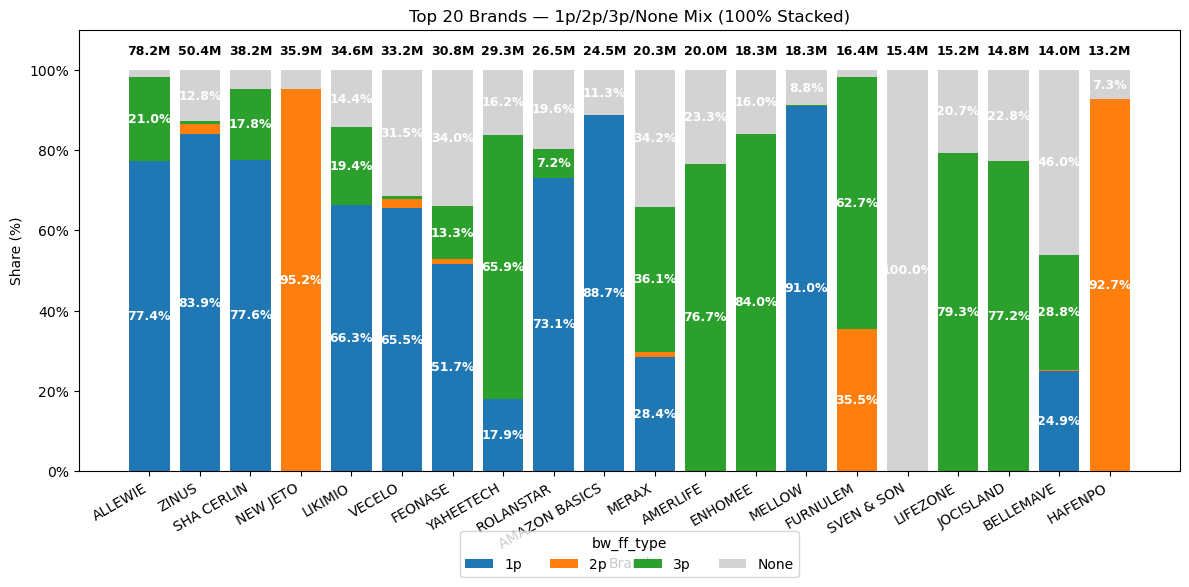

In [66]:
from matplotlib.ticker import FuncFormatter

# ===== 총매출 기준으로 정렬 =====
order = pivot_sales.sum(axis=1).sort_values(ascending=False).index
pivot_sales = pivot_sales.loc[order]
ratio = ratio.loc[order]  # 비중 테이블도 동일 순서로 정렬

# ===== 100% 누적 막대 그래프 =====
colors = {'1p': '#1f77b4', '2p': '#ff7f0e', '3p': '#2ca02c', 'None': 'lightgray'}
plot_cols = ['1p', '2p', '3p', 'None']

fig, ax = plt.subplots(figsize=(12, 6))

bottom = np.zeros(len(pivot_sales))
x = np.arange(len(pivot_sales))

# 비중(%) 데이터로 그리기
for col in plot_cols:
    vals = ratio[col].values
    ax.bar(x, vals, bottom=bottom, label=col, color=colors[col])
    bottom += vals

# x축 라벨: 브랜드명
ax.set_xticks(x)
ax.set_xticklabels(pivot_sales.index, rotation=30, ha='right')
ax.set_xlabel("Brand")

# y축: 0~100%
ax.set_ylim(0, 110)  # 위에 총매출 라벨 표시 공간 확보
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.0f}%"))
ax.set_ylabel("Share (%)")
ax.set_title("Top 20 Brands — 1p/2p/3p/None Mix (100% Stacked)")

# Legend: 아래쪽으로 이동
ax.legend(title="bw_ff_type", ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.12))

# 각 세그먼트에 비중(%) 라벨 (아주 작은 조각은 생략)
min_ratio_to_show = 5.0
for i, brand in enumerate(ratio.index):
    y_base = 0.0
    for col in plot_cols:
        val = ratio.loc[brand, col]
        if val <= 0:
            continue
        if val >= min_ratio_to_show:
            ax.text(
                i, y_base + val/2,
                f"{val:.1f}%",
                ha='center', va='center',
                fontsize=9, color='white', weight='bold'
            )
        y_base += val

# ===== 총매출 라벨 (Million 단위) =====
totals = pivot_sales.sum(axis=1).values
for i, total in enumerate(totals):
    ax.text(
        i, 103,  # 막대 상단 조금 위
        f"{total/1e6:.1f}M",
        ha='center', va='bottom', fontsize=9, weight='bold'
    )

plt.tight_layout()
plt.show()

In [68]:
# 1) 2025년 데이터만
df_2025 = df1[df1['year'] == 2025].copy()

# 2) bw_ff_type NaN -> 'None'
df_2025['bw_ff_type'] = df_2025['bw_ff_type'].fillna('None')

# 3) 브랜드명 정규화 (대문자 + 공백 제거)
df_2025['Brand_raw'] = df_2025['Brand_raw'].str.strip().str.upper()

# 4) 매출 기준 Top 20 브랜드 선정
brand_sales = (
    df_2025.groupby('Brand_raw', dropna=False)['RetailSales']
      .sum()
      .sort_values(ascending=False)
)
print("▶ Top 20 브랜드 (매출 기준)")
print(brand_sales.head(20))

top20_brands = list(brand_sales.head(20).index)

# 5) Top 20만 필터링
df_top = df_2025[df_2025['Brand_raw'].isin(top20_brands)].copy()

# 6) bw_ff_type별 유니크 RetailerSku 개수 피벗 (브랜드 x bw_ff_type)
pivot_sku = (
    df_top.pivot_table(
        index='Brand_raw',
        columns='bw_ff_type',
        values='RetailerSku',
        aggfunc=lambda x: x.nunique(),  # 유니크 SKU 개수
        fill_value=0
    )
)

# 7) 컬럼 순서 고정 및 누락 컬럼 보강
desired_cols = ['1p', '2p', '3p', 'None']
for c in desired_cols:
    if c not in pivot_sku.columns:
        pivot_sku[c] = 0
pivot_sku = pivot_sku[desired_cols]

# 8) 브랜드 순서를 "매출 Top 20" 순서로 고정
pivot_sku = pivot_sku.reindex(top20_brands).fillna(0).astype(int)

# 9) 비중(%) 계산 (행 기준 합 대비)
sku_ratio = pivot_sku.div(pivot_sku.sum(axis=1).replace(0, 1), axis=0) * 100

# 10) 표 출력
print("\n▶ Top 20 브랜드의 bw_ff_type별 유니크 RetailerSku 개수")
print(pivot_sku)

print("\n▶ Top 20 브랜드의 bw_ff_type별 유니크 RetailerSku 비중(%)")
print(sku_ratio.round(1))

▶ Top 20 브랜드 (매출 기준)
Brand_raw
ALLEWIE          78205655.58
ZINUS            50353688.12
SHA CERLIN       38236404.00
NEW JETO         35851570.79
LIKIMIO          34610328.62
VECELO           33163580.22
FEONASE          30842645.85
YAHEETECH        29342483.81
ROLANSTAR        26540426.89
AMAZON BASICS    24507299.61
MERAX            20265508.84
AMERLIFE         20022064.10
ENHOMEE          18268158.68
MELLOW           18250288.43
FURNULEM         16379411.14
SVEN & SON       15381199.45
LIFEZONE         15211676.82
JOCISLAND        14786166.82
BELLEMAVE        13993034.15
HAFENPO          13235696.33
Name: RetailSales, dtype: float64

▶ Top 20 브랜드의 bw_ff_type별 유니크 RetailerSku 개수
bw_ff_type       1p  2p   3p  None
Brand_raw                         
ALLEWIE         233   0  188   128
ZINUS           380   8   22   263
SHA CERLIN      214   0  206    94
NEW JETO          0  16    0     6
LIKIMIO         126   0  105   139
VECELO         1257  35   51  1048
FEONASE         170   7   52 

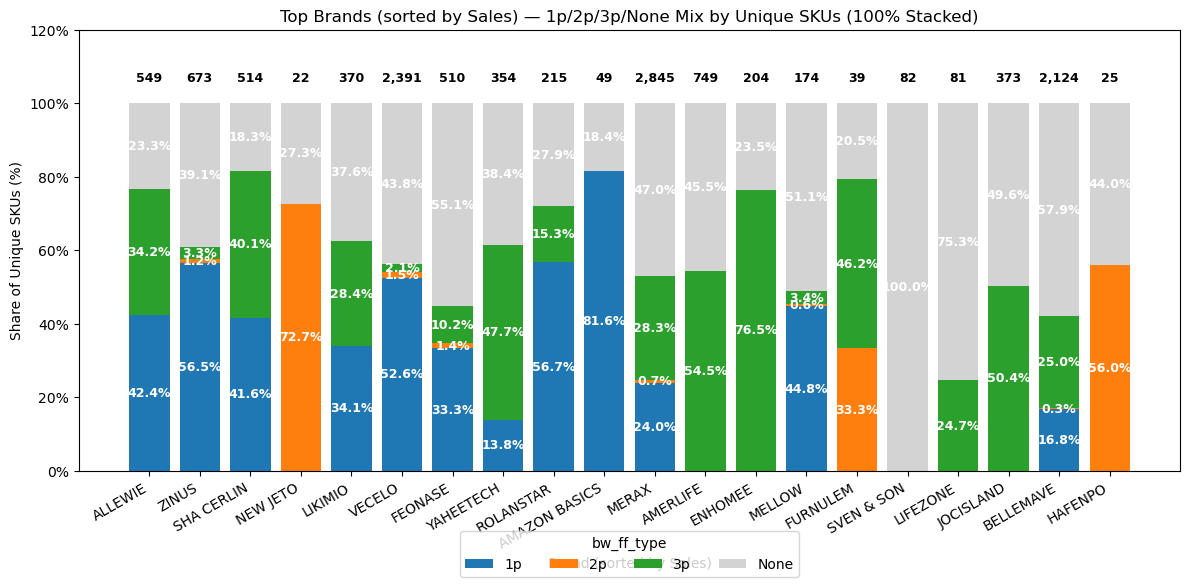

In [76]:
from matplotlib.ticker import FuncFormatter

# ===== 매출 기준 Top 브랜드 순서 =====
order = pivot_sales.sum(axis=1).sort_values(ascending=False).index  # 매출 기준 순서
pivot_sku = pivot_sku.loc[order.intersection(pivot_sku.index)]
sku_ratio  = sku_ratio.loc[pivot_sku.index]

# ===== 100% 누적 막대 그래프 (SKU 비중) =====
colors = {'1p': '#1f77b4', '2p': '#ff7f0e', '3p': '#2ca02c', 'None': 'lightgray'}
plot_cols = ['1p', '2p', '3p', 'None']

fig, ax = plt.subplots(figsize=(12, 6))

bottom = np.zeros(len(pivot_sku))
x = np.arange(len(pivot_sku))

# 비중(%) 데이터로 누적 막대
for col in plot_cols:
    vals = sku_ratio[col].values
    ax.bar(x, vals, bottom=bottom, label=col, color=colors[col])
    bottom += vals

# x축 라벨: 매출 순서 브랜드
ax.set_xticks(x)
ax.set_xticklabels(pivot_sku.index, rotation=30, ha='right')
ax.set_xlabel("Brand (sorted by Sales)")

# y축: 0~100%
ax.set_ylim(0, 120)  # 상단에 SKU 개수 라벨 공간 확보
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.0f}%"))
ax.set_ylabel("Share of Unique SKUs (%)")
ax.set_title("Top Brands (sorted by Sales) — 1p/2p/3p/None Mix by Unique SKUs (100% Stacked)")

# Legend: 제목과 겹치지 않게 아래쪽으로
ax.legend(title="bw_ff_type", ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.12))

# ===== 각 세그먼트에 비중(%) 표시 (모두 흰색) =====
for i, brand in enumerate(sku_ratio.index):
    y_base = 0
    for col in plot_cols:
        val = sku_ratio.loc[brand, col]
        if val > 0:
            ax.text(
                i, y_base + val/2,
                f"{val:.1f}%",
                ha='center', va='center',
                fontsize=9, color="white", weight='bold'
            )
        y_base += val

# ===== 막대 상단에 유니크 SKU 총개수 표시 =====
sku_totals = pivot_sku.sum(axis=1).values
for i, total in enumerate(sku_totals):
    ax.text(
        i, 105,  # 막대 위 조금 위쪽
        f"{int(total):,}",  # 천 단위 콤마
        ha='center', va='bottom', fontsize=9, weight='bold'
    )

plt.tight_layout()
plt.show()